In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os

project_path = "/content/drive/MyDrive/fish_classification_project"

os.makedirs(project_path, exist_ok=True)

print("Project folder ready:", project_path)

Project folder ready: /content/drive/MyDrive/fish_classification_project


In [ ]:
project_path = "/content/drive/MyDrive/fish_classification_project"

In [2]:
import zipfile

project_path = "/content/drive/MyDrive/fish_classification_project"

zip_path = project_path + "/fish_dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(project_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [3]:
import os

os.listdir(project_path)

['fish_dataset.zip', 'fish_dataset', '__MACOSX']

In [4]:
os.listdir(project_path + "/fish_dataset")

['test', 'train', 'val']

In [5]:
!cp -r /content/drive/MyDrive/fish_classification_project/fish_dataset /content/

In [6]:
!ls /content/fish_dataset

test  train  val


In [7]:
!pip install timm

In [8]:
import torch
import torch.nn as nn
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("/content/fish_dataset/train", transform=train_transform)
val_dataset = datasets.ImageFolder("/content/fish_dataset/val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64)

print("Classes:", train_dataset.classes)
print("Total training images:", len(train_dataset))

Classes: ['Type 1 Pomfret', 'Type 2 Mackerel', 'Type 3 Black Snapper', 'Type 4 Indian Carp', 'Type 5 Prawn', 'Type 6 Pink Perch', 'Type 7 Indian Carp', 'Type 8 Black Pomfret', 'Type 9 Tuna']
Total training images: 7051


In [10]:
class AttentionBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim,8,batch_first=True)

    def forward(self,x):
        x,_ = self.attn(x,x,x)
        return x


class AquaFormerNet(nn.Module):

    def __init__(self,num_classes):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            num_classes=0
        )

        dim = self.backbone.num_features

        self.attn = AttentionBlock(dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=8,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Linear(dim,num_classes)

    def forward(self,x):

        x = self.backbone(x)

        x = x.unsqueeze(1)

        x = self.attn(x)

        x = self.transformer(x)

        x = x.mean(dim=1)

        x = self.fc(x)

        return x

In [11]:
device = torch.device("cuda")

model = AquaFormerNet(len(train_dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0003)

epochs = 15

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, pred = torch.max(outputs,1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

    acc = 100 * correct / total

    print(f"Epoch {epoch+1} Loss:{total_loss:.3f} Accuracy:{acc:.2f}%")

    torch.save(
        model.state_dict(),
        project_path + f"/aquaformer_epoch_{epoch+1}.pth"
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

100%|██████████| 111/111 [01:10<00:00,  1.57it/s]


Epoch 1 Loss:9.022 Accuracy:97.50%


100%|██████████| 111/111 [01:06<00:00,  1.66it/s]


...

Epoch 13 Loss:2.479 Accuracy:99.87%


100%|██████████| 111/111 [01:06<00:00,  1.66it/s]


Epoch 14 Loss:4.578 Accuracy:99.48%


100%|██████████| 111/111 [01:09<00:00,  1.60it/s]


Epoch 15 Loss:1.409 Accuracy:99.76%


In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

device = torch.device("cuda")

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder("/content/fish_dataset/test", transform=test_transform)

test_loader = DataLoader(test_dataset, batch_size=64)

model = AquaFormerNet(len(test_dataset.classes)).to(device)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/fish_classification_project/aquaformer_epoch_15.pth")
)

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 99.07651715039577


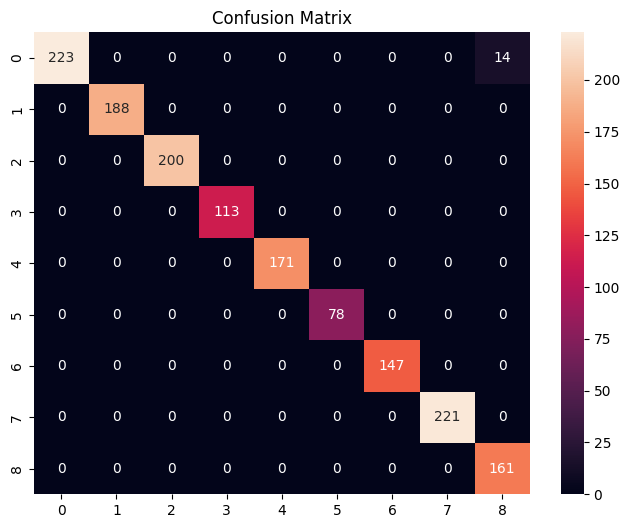

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()